# Monte Carlo Simulation: Testing Decisions Under Uncertainty

This notebook is written for **business and analytics students**, not programmers. You do **not** need to memorize Python. Your job is to **read the story**, run each code cell in order (Shift+Enter in Jupyter, or the play button in Colab), and connect the **printed numbers and charts** back to the staffing decision.

This notebook demonstrates Monte Carlo simulation as a tool for testing decisions against real-world uncertainty.

Understanding this is critical because:
- **Optimization gives you one answer** — the best plan under your assumptions
- **Real conditions vary** — demand, costs, and arrival times are never exactly what you assumed
- **Simulation tests your decision** against thousands of realistic scenarios
- **The result is a distribution**, not a number — and that distribution tells you how reliable your plan actually is

**How to get value from this notebook**
1. Run the setup cells so packages load and plots appear in this document.
2. Read the markdown *above* each code block first — it explains what the code is computing in plain language.
3. After the code runs, ask: *Do the tables and histograms match the story?* Surprises are part of the lesson.


## Key Concepts

**Deterministic model:**  
Assumes inputs are known. Gives one output: "Staff 12 nurses per shift." That feels decisive, but it is **fragile** — it is built on a single assumed demand value.

**Monte Carlo simulation:**  
- Pick a decision (for example, "staff 12 nurses").
- Describe how uncertain inputs vary (for example, patient arrivals vary around an average).
- Run that decision through **many** randomly generated scenarios (here, 1,000).
- Collect all outcomes into a **distribution** (a whole pattern of results, not one number).

**How to read percentiles (plain English):**
- **Mean (average):** the balancing point of all outcomes — useful, but it hides bad luck.
- **5th percentile (P5):** if you lined up all outcomes from worst to best, P5 is still fairly far toward the "bad" end — a common way to think about **downside / tail risk**.
- **95th percentile (P95):** far toward the "good" end — useful when you care about upside or best-case-ish outcomes.

In this notebook, we focus on **mean cost** and **P95 cost** as simple, manager-friendly summaries of the distribution.

**What the distribution tells you:**
- **Mean outcome** — the average result across all scenarios
- **Tail points (like P5 / P95)** — how bad (or how good) it can get in extreme scenarios
- **Shape** — tight and centered often means more predictable; wide or skewed often means riskier

**Connection to Lesson 5:** Sensitivity analysis tested one uncertain input at a time ("what if demand rises 10%?"). Simulation tests uncertain inputs **together**, many times, which is closer to how the real world behaves all at once.


## Scenario: Hospital Shift Staffing

A hospital manager must decide how many nurses to schedule per shift.

- Average patient demand: **50 patients per shift**
- Each nurse can handle **5 patients**
- A fully staffed 10-nurse shift would cover average demand exactly (10 × 5 = 50)
- But patient arrivals are **uncertain** — in the model, they vary around the average (like real life)

The manager's options in this teaching example: staff **10, 11, 12, or 13** nurses.

The question simulation answers: **"If I pick a staffing level and the world varies day to day, what costs and service failures should I expect — especially on bad days?"**


## Step 1: Install Required Packages

**What you are doing:** making sure this environment can run the notebook.

- In **Google Colab**, it is common to install packages from inside the notebook.
- On many classroom/lab machines, these packages may already be installed — running this cell is still safe.

**What `%pip install ...` means (non-programmer version):** it asks Python's package manager to download small libraries the notebook uses. The `-q` flag just means "quiet" (less text in the output).


In [1]:
# Install required packages (if needed in Colab)
%pip install numpy matplotlib pandas -q


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Step 2: Import Libraries

**What you are doing:** loading three standard tools used for calculation and charts:

- **`numpy` (`np`)**: fast random-number generation and arithmetic on many scenarios at once
- **`pandas` (`pd`)**: neat tables for summarizing results
- **`matplotlib.pyplot` (`plt`)**: histograms (distribution pictures)

**`np.random.seed(42)`** makes the "random" scenarios **repeatable** for teaching — the same seed produces the same sequence of random demands, so your numbers match the course materials. In real analysis you might not fix the seed, or you would run enough scenarios that the big lessons do not depend on a single draw.

**Goal:** not programming practice — just preparing the workspace so we can focus on the *idea* of Monte Carlo simulation.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## Step 3: The Deterministic Baseline

**Story:** many organizations start with a simple spreadsheet mindset: use an average forecast, divide by productivity, round up, and call it "the plan."

**What the code is doing (read it like a recipe):**
- It sets a few **policy numbers**: expected demand, how many patients a nurse can cover, nurse shift cost, and a penalty cost when demand is not fully covered.
- It computes `nurses_needed` using the average demand only.
- It prints a **single** projected cost and assumes **zero** unmet demand — because the deterministic view pretends demand is *exactly* the average.

**What to look for in the output:** a clean, confident answer that ignores day-to-day variation. The printout ends by stating the problem plainly: real demand is not always the average.


In [3]:
# === DETERMINISTIC MODEL ===
avg_demand       = 50      # expected patients per shift
nurse_capacity   = 5       # patients per nurse
cost_per_nurse   = 400     # dollars per shift
overload_penalty = 200     # cost per patient who can't be seen (understaffing penalty)

# Simple rule: hire enough nurses for average demand
nurses_needed = int(np.ceil(avg_demand / nurse_capacity))

projected_cost   = nurses_needed * cost_per_nurse
projected_unmet  = 0  # assumes demand equals average exactly

print("=== DETERMINISTIC MODEL ===")
print(f"Average demand:          {avg_demand} patients")
print(f"Nurses recommended:      {nurses_needed}")
print(f"Projected shift cost:    ${projected_cost:,}")
print(f"Projected unmet demand:  {projected_unmet} patients")
print()
print("Problem: this assumes demand is always exactly 50. It never is.")

=== DETERMINISTIC MODEL ===
Average demand:          50 patients
Nurses recommended:      10
Projected shift cost:    $4,000
Projected unmet demand:  0 patients

Problem: this assumes demand is always exactly 50. It never is.


## Step 4: Run Monte Carlo Simulation

**Story:** now we keep the same costs and rules, but we no longer assume demand is fixed. We draw **1,000** random demand levels for each staffing option and record what happens each time.

**What the code is doing (plain English):**
- `n_scenarios = 1_000` means "repeat the world 1,000 times."
- For each nurse count in `staffing_levels`, it computes **capacity** (nurses × patients per nurse).
- `np.random.normal(...)` generates many demand draws around the average, with spread controlled by `demand_std`.
- `np.clip(..., 0, None)` prevents negative demand (a modeling convenience).
- For each scenario, **unmet demand** is the amount demand exceeds capacity (or zero if capacity is enough).
- **Total cost** is shift cost plus penalties for unmet demand.
- The code stores summaries: mean cost, P95 cost, percent of scenarios with any unmet demand, and the full list of costs for plotting.

**After you run it:** scan the table. You should see staffing levels that look "cheap on average" but have scary **P95 cost** or high **% understaffed** — that tension is the point.


In [4]:
# === MONTE CARLO SIMULATION ===
n_scenarios     = 1_000
demand_mean     = 50
demand_std      = 8
staffing_levels = [10, 11, 12, 13]  # candidate decisions to test

results = {}

for nurses in staffing_levels:
    capacity      = nurses * nurse_capacity
    shift_cost    = nurses * cost_per_nurse
    
    # Generate 1,000 random demand scenarios
    demands = np.random.normal(demand_mean, demand_std, n_scenarios)
    demands = np.clip(demands, 0, None)  # demand can't be negative
    
    # For each scenario: how many patients go unmet? What is total cost?
    unmet    = np.maximum(0, demands - capacity)
    penalties = unmet * overload_penalty
    total_costs = shift_cost + penalties
    
    pct_understaffed = np.mean(unmet > 0) * 100
    
    results[nurses] = {
        "mean_cost":         np.mean(total_costs),
        "p5_cost":           np.percentile(total_costs, 5),
        "p95_cost":          np.percentile(total_costs, 95),
        "pct_understaffed":  pct_understaffed,
        "mean_unmet":        np.mean(unmet),
        "worst_unmet":       np.percentile(unmet, 95),
        "all_costs":         total_costs
    }

print("Simulation complete — 1,000 scenarios per staffing level.")
print()
print(f"{'Nurses':>8} {'Mean Cost':>12} {'P95 Cost':>12} {'% Understaffed':>16} {'Worst Unmet (P95)':>18}")
print("-" * 72)
for n, r in results.items():
    print(f"{n:>8} ${r['mean_cost']:>10,.0f} ${r['p95_cost']:>10,.0f} {r['pct_understaffed']:>14.1f}%  {r['worst_unmet']:>16.1f} pts")

Simulation complete — 1,000 scenarios per staffing level.

  Nurses    Mean Cost     P95 Cost   % Understaffed  Worst Unmet (P95)
------------------------------------------------------------------------
      10 $     4,639 $     6,683           51.0%              13.4 pts
      11 $     4,688 $     6,113           28.0%               8.6 pts
      12 $     4,880 $     5,388            9.9%               2.9 pts
      13 $     5,217 $     5,200            3.5%               0.0 pts


## Step 5: Read the Distribution

**Story:** optimization (by itself) often returns **one** recommended number. Simulation returns a **whole histogram**: how often outcomes cluster, and how often extreme costs happen.

**What the charts show:**
- Each subplot is one staffing level.
- The **histogram** counts how many simulated weeks land at each total cost.
- The **dashed black line** marks the **mean** total cost.
- The **dotted red line** marks **P95 total cost** — a simple "bad week" summary (not the single worst week, but far up the bad tail).
- The **green line** marks the **best-case shift cost** (paying nurses only — no penalty), which helps you see how much of the cost risk comes from penalties.

**How to interpret in one sentence:** if the histogram has a long "tail" stretching to the right, occasional very expensive weeks happen — even if the average looks acceptable.


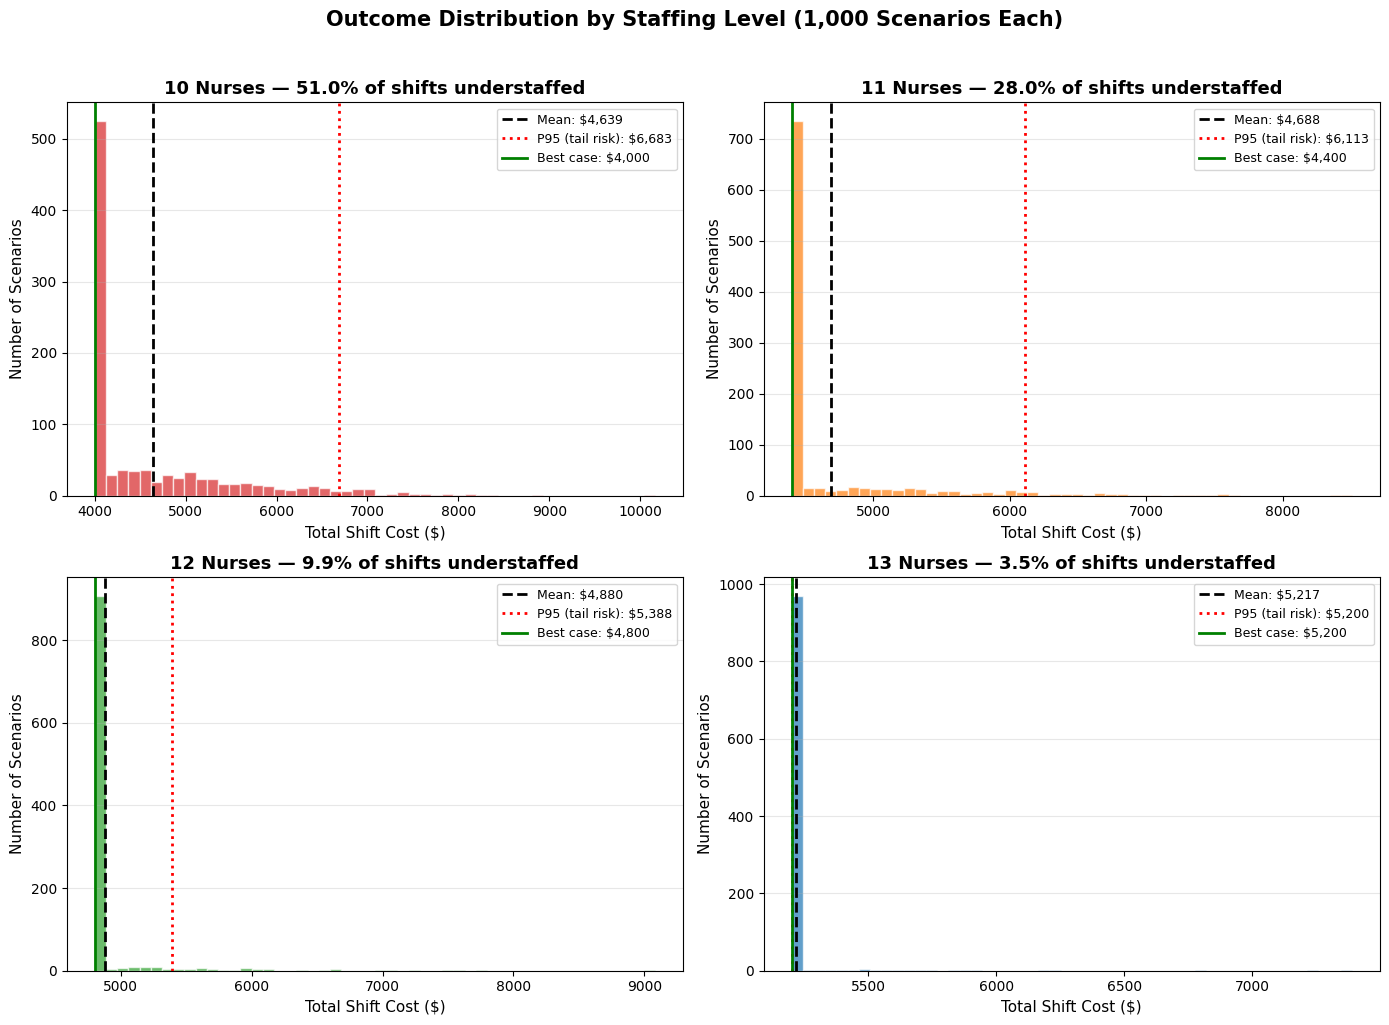


Key insight: wide distributions = sensitive to conditions. Narrow = reliable.
A plan with a high mean cost but narrow distribution may be preferable to a
cheap plan with a long right tail (rare but very costly failures).


In [5]:
# === VISUALIZE THE OUTCOME DISTRIBUTIONS ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

for idx, (nurses, r) in enumerate(results.items()):
    ax = axes[idx]
    costs = r['all_costs']
    
    ax.hist(costs, bins=50, color=colors[idx], alpha=0.7, edgecolor='white')
    ax.axvline(r['mean_cost'],  color='black',  linestyle='--', lw=2, label=f"Mean: ${r['mean_cost']:,.0f}")
    ax.axvline(r['p95_cost'],   color='red',    linestyle=':',  lw=2, label=f"P95 (tail risk): ${r['p95_cost']:,.0f}")
    ax.axvline(nurses * cost_per_nurse, color='green', linestyle='-', lw=2, label=f"Best case: ${nurses*cost_per_nurse:,}")
    
    ax.set_title(f"{nurses} Nurses — {r['pct_understaffed']:.1f}% of shifts understaffed", 
                 fontsize=13, fontweight='bold')
    ax.set_xlabel("Total Shift Cost ($)", fontsize=11)
    ax.set_ylabel("Number of Scenarios", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Outcome Distribution by Staffing Level (1,000 Scenarios Each)", 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print()
print("Key insight: wide distributions = sensitive to conditions. Narrow = reliable.")
print("A plan with a high mean cost but narrow distribution may be preferable to a")
print("cheap plan with a long right tail (rare but very costly failures).")

## Step 6: Make the Decision

**Story:** simulation does not replace leadership judgment — it **feeds** judgment with probabilities and tradeoffs.

**What the code is doing:** it builds a readable table (`pandas`) that lines up staffing choices side by side on a few metrics managers actually argue about: average cost, tail cost, how often you fail to cover demand, and a worst-case-ish unmet demand summary.

**After you run it:** use the printed questions like a checklist. Different hospitals (and different ethical risk tolerances) can legitimately choose different staffing levels even with the same simulation output.


In [6]:
# === DECISION SUMMARY TABLE ===
summary_rows = []
for nurses, r in results.items():
    summary_rows.append({
        "Staffing Level": f"{nurses} nurses",
        "Mean Shift Cost": f"${r['mean_cost']:,.0f}",
        "Tail Risk (P95 Cost)": f"${r['p95_cost']:,.0f}",
        "Shifts Understaffed": f"{r['pct_understaffed']:.1f}%",
        "Worst-Case Unmet Demand (P95)": f"{r['worst_unmet']:.1f} patients"
    })

df_summary = pd.DataFrame(summary_rows)
print("=== DECISION SUMMARY ===")
print(df_summary.to_string(index=False))
print()
print("Questions a manager must answer before deciding:")
print("  1. What is an acceptable understaffing rate? (e.g., under 5%?)")
print("  2. What is the cost of a patient going unserved vs. a nurse shift?")
print("  3. How much tail risk is acceptable?")
print()
print("Optimization alone says: '10 nurses covers average demand.'")
pct10 = results[10]["pct_understaffed"]
print(
    f"Simulation says: 'With 10 nurses, demand exceeds capacity in about {pct10:.0f}% of simulated shifts.'"
)
print("The right answer depends on the manager's risk tolerance — not just the math.")

=== DECISION SUMMARY ===
Staffing Level Mean Shift Cost Tail Risk (P95 Cost) Shifts Understaffed Worst-Case Unmet Demand (P95)
     10 nurses          $4,639               $6,683               51.0%                 13.4 patients
     11 nurses          $4,688               $6,113               28.0%                  8.6 patients
     12 nurses          $4,880               $5,388                9.9%                  2.9 patients
     13 nurses          $5,217               $5,200                3.5%                  0.0 patients

Questions a manager must answer before deciding:
  1. What is an acceptable understaffing rate? (e.g., under 5%?)
  2. What is the cost of a patient going unserved vs. a nurse shift?
  3. How much tail risk is acceptable?

Optimization alone says: '10 nurses covers average demand.'
Simulation says: 'With 10 nurses, demand exceeds capacity in about 51% of simulated shifts.'
The right answer depends on the manager's risk tolerance — not just the math.


## Key Takeaways (Outro)

1. **Deterministic models give one answer.** Simulation gives you a **distribution** — a picture of how outcomes spread when the world varies.

2. **The distribution reveals tail risk** — the costly or dangerous scenarios that a single "expected value" mindset can hide.

3. **"Optimal under assumptions" ≠ "best in practice."** A plan that looks efficient at the average can still fail often when reality jitters around that average.

4. **Simulation does not choose for you.** It translates assumptions into **frequencies and severities**. The organization's risk tolerance turns that into a decision.

5. **When simulation is worth the effort:** when inputs are genuinely uncertain **and** the cost of being wrong is high enough to justify stress-testing.

**Close the loop:** if you can explain *why* a higher staffing level might be rational even when it costs more on average, you understand Monte Carlo as a **risk communication** tool — not a black box.

**Next notebook:** we combine optimization and simulation into a two-step workflow — optimize first, then simulate to stress-test the recommendation.
